# Extracting bird song signatures with wavelets

https://www.kaggle.com/code/mistag/extracting-bird-song-signatures-with-wavelets/notebook

## Wavelets



Everyone knows the Fourier transform where (stationary) signals are represented as a sum of sinusoids, and the standard transform is only localized in frequency. [Wavelets](https://en.wikipedia.org/wiki/Wavelet) on the other hand are localized in both time and frequency. Wavelets have proven to perform well in many ML applications on non-stationary signals. The two main approaches of using wavelets are:
* Discrete wavelet transform (DWT): A signal is broken down into subbands, from which features are extracted and used as input to ML models.
* Continuous wavelet transform (CWT): A scaleogram can be constructed from the signal. The scaleogram can be compared to a spectrogram when using FFT. Scaleogram images can then be used as input to an image classification model.  

In this notebook we will look into how to create scaleograms from bird song signatures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import matplotlib.image as mpimg
import librosa
import warnings
warnings.filterwarnings('ignore') # get rid of librosa warnings

We could use [PyWavelets](https://pywavelets.readthedocs.io/en/latest/) for the CWT, but here we will use a modified version of [Alexander Neergaard's CWT](https://github.com/aneergaard/CWT). Specifically a parameter is added to allow cutting off the longest wavelets (lowest frequencies).

In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('../src'))
from cwt import cwt2, rd_file, cwt3

from IPython.display import Audio
from sklearn.preprocessing import minmax_scale

TRAIN_DIR = '../data/sound/cornell-birdcall/train_audio'
SR = 22050 # sample rate in Hz


## FFT vs Spectrogram vs Scaleogram
First we will take a look at the difference between the standard FFT, the spectrogram and the scaleogram.

In [3]:
import scipy.fftpack
from scipy import signal
from scipy.signal import chirp

DB_RANGE = 100 # dynamic range to show in dB
SR = 22050
CMAP = 'magma'


In [ ]:

def show_sigx3(d):
    fig, axes = plt.subplots(1, 3, figsize=(16,5))
    # FFT
    N, T = SR, 1./SR
    x = np.linspace(0.0, int(N*T), N)
    yf = scipy.fftpack.fft(d*np.hamming(len(d)))
    xf = np.linspace(0.0, 1.0/(2.0*T), N//2)
    axes[0].plot(xf,  20*np.log10(2.0/N *np.abs(yf[:N//2])))
    axes[0].set_ylim(-80,0)
    axes[0].set_title('FFT')
    # Spectrogram
    f, t, Sxx = signal.spectrogram(d, SR)
    axes[1].pcolormesh(t, f, 20*np.log10(Sxx), shading='auto', cmap=CMAP, vmax=-60, vmin=-60-DB_RANGE)
    axes[1].set_title('Spectrogram')
    # CWT
    #cs, f = calc_cwt(d)
    cs, f = cwt2(d, nv=12, sr=SR, low_freq=40)
    axes[2].imshow(20*np.log10(np.abs(cs)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-DB_RANGE)
    axes[2].set_title('Scaleogram')
    plt.show()

## Random noise

size of x: 44100, memory of x 352800
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.815912

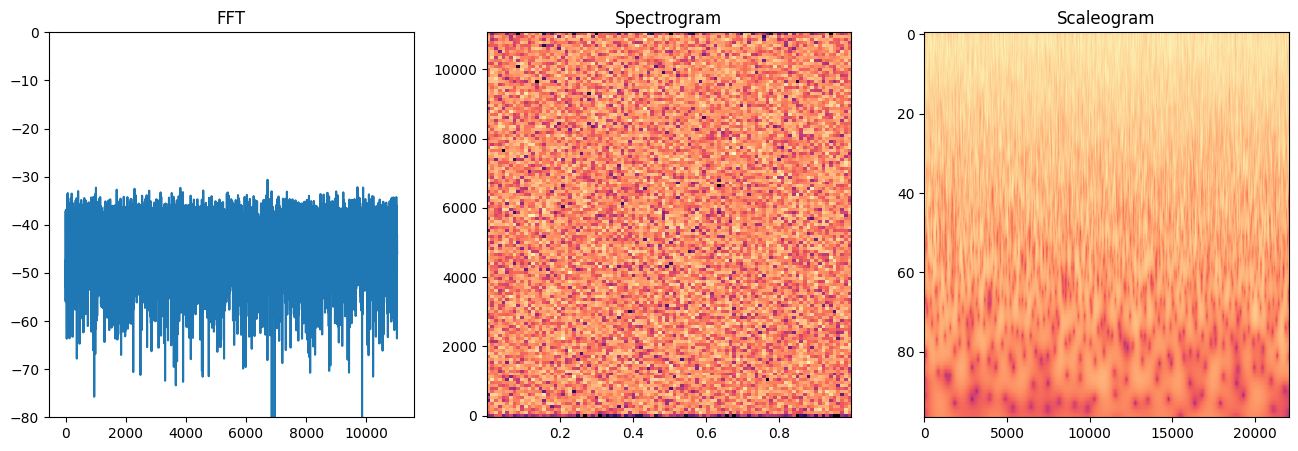

In [4]:
d = np.random.randn(SR)
show_sigx3(d)

The scaleogram has high temporal resolution but poor frequency resolution at small scales (high frequencies), and high frequency resolution but poor temporal resolution at large scales (low frequencies).

## Chirp

size of x: 44100, memory of x 352800
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.815912

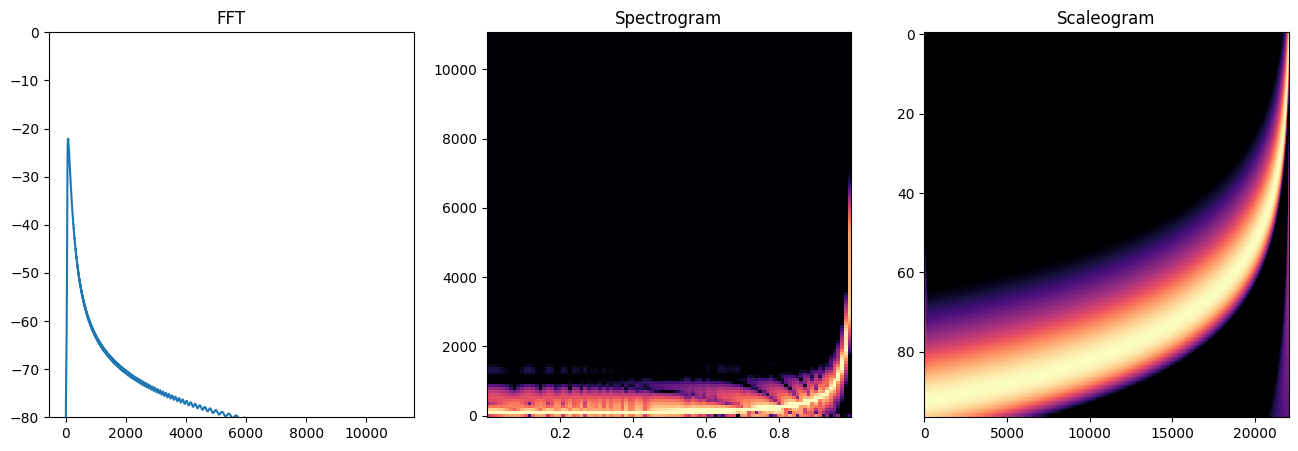

In [5]:
t = np.linspace(0, 1, SR)
d = chirp(t, f0=50, f1=10e3, t1=1., method='hyperbolic')
show_sigx3(d)

Already we can see that scaleograms generally appears smoother than spectrograms, and with less artifacts. 

# Bird songs

Right, let's look at some bird song recordings. Will resample all recordings to mono, 22050Hz.

In [7]:
# load a file with Black-throated Blue Warbler
d1 = rd_file(TRAIN_DIR+'/btbwar/XC139608.mp3')
Audio(d1, rate=SR)

data type: float32
data size should be 1707264.0
size of rd_file data: 1707264


In [8]:
# load another file with Black-throated Green Warbler
d2 = rd_file(TRAIN_DIR+'/btnwar/XC135117.mp3')
Audio(d2, rate=SR)

data type: float32
data size should be 5292000.0
size of rd_file data: 5292000


* Now, make a wavelet transform of the audio recordings and plot the scaleograms for these two files. 

size of x: 853632, memory of x 3414528
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.8159

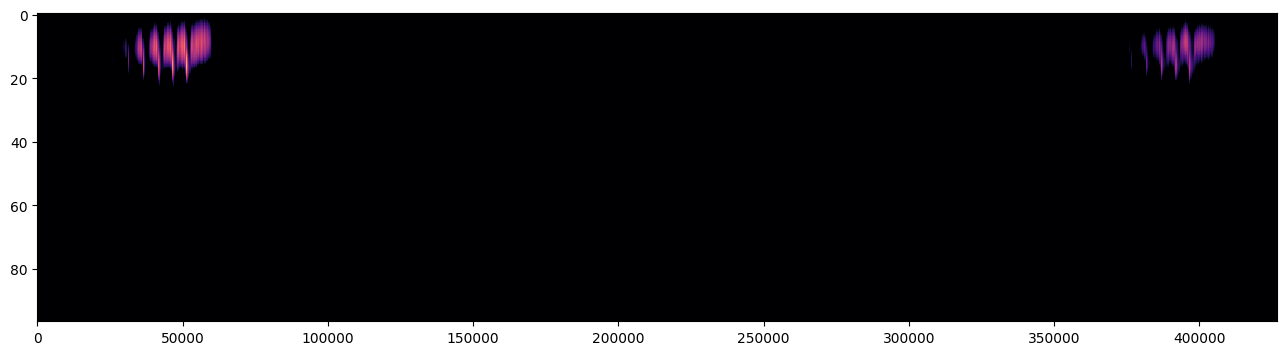

In [9]:
cs1, f1 = cwt2(d1, nv=12, sr=SR, low_freq=40)
print(f'shape of cs1: {cs1.shape}')
print(f'cs1:\n{cs1[10][52000:52020]}')
print(f'shape of f1: {f1.shape}')
plt.figure(figsize = (16,4))
plt.imshow(20*np.log10(np.abs(cs1)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-30)
plt.show()

size of x: 2646000, memory of x 10584000
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.81

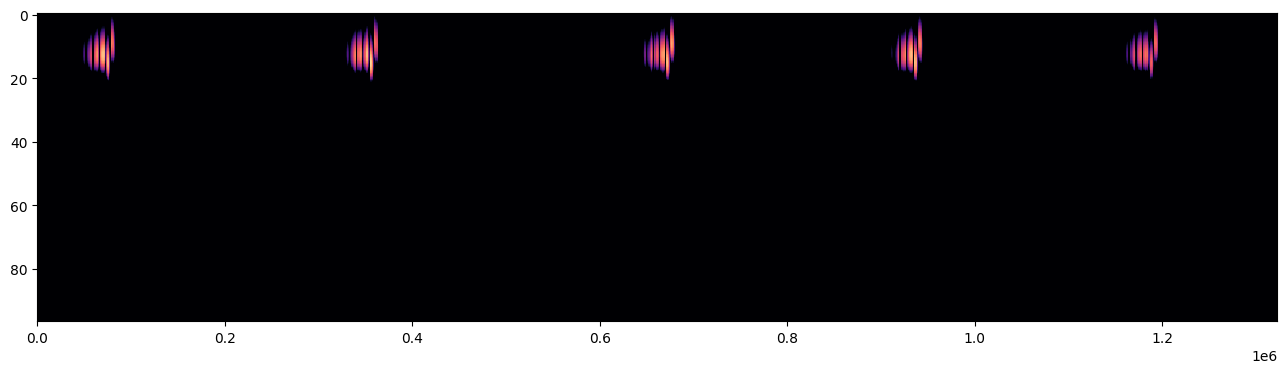

In [10]:
cs2, f2 = cwt2(d2, nv=12, sr=SR, low_freq=40)
plt.figure(figsize = (16,4))
plt.imshow(20*np.log10(np.abs(cs2)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-30)
plt.show()

In [11]:
def plot_sigx2(d1, d2, name1='data 1', name2='data 2', cwt=True, db_range=30):
    fig, axes = plt.subplots(1, 2, figsize=(16,4))
    d = [d1, d2]
    name = [name1, name2]
    for i in range(2):
        if cwt == True:
            cs, _ = cwt2(d[i], nv=12, sr=SR, low_freq=40)
            axes[i].imshow(20*np.log10(np.abs(cs)),  cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-db_range)
        else:
            f, t, Sxx = signal.spectrogram(d[i], SR)
            axes[i].pcolormesh(t, f, 20*np.log10(Sxx), shading='auto', cmap=CMAP, vmax=-60, vmin=-60-db_range)
        axes[i].set_title(name[i])
    plt.show()

We can clearly see the calls. Let's zoom in on a single call from the two species.

size of x: 80000, memory of x 320000
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.815912

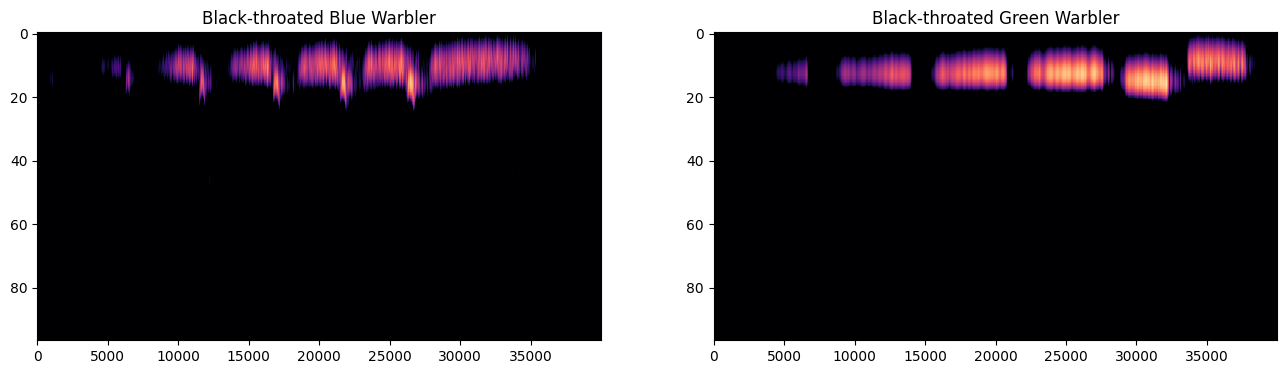

In [12]:
plot_sigx2(d1[25000:65000], d2[45000:85000], 
           name1='Black-throated Blue Warbler', name2='Black-throated Green Warbler')

A clear difference! For comparison, let's look at the spectrograms of the same signals.

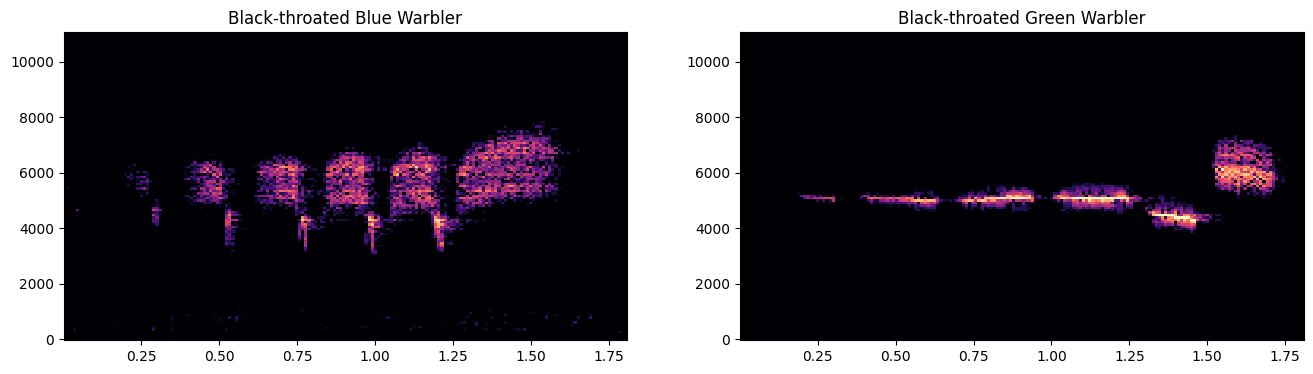

In [13]:
plot_sigx2(d1[25000:65000], d2[45000:85000], 
           name1='Black-throated Blue Warbler', name2='Black-throated Green Warbler', cwt=False, db_range=60)

Notice that we are using a threshold function (coefficients below -30dB are set to zero) on the amplitudes of the coefficients here to remove background noise. If we include a larger dynamic range, plots look quite different:

size of x: 80000, memory of x 320000
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.815912

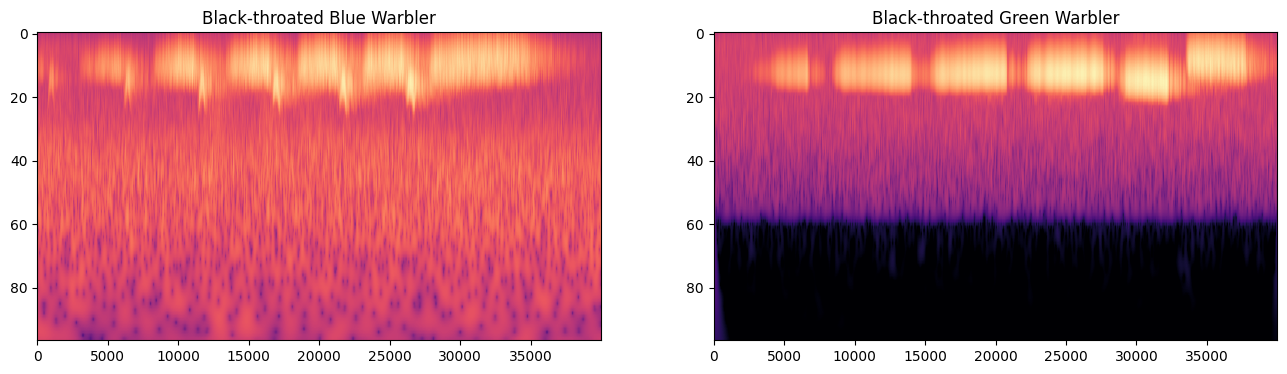

In [14]:
plot_sigx2(d1[25000:65000], d2[45000:85000], 
           name1='Black-throated Blue Warbler', name2='Black-throated Green Warbler', db_range=120)

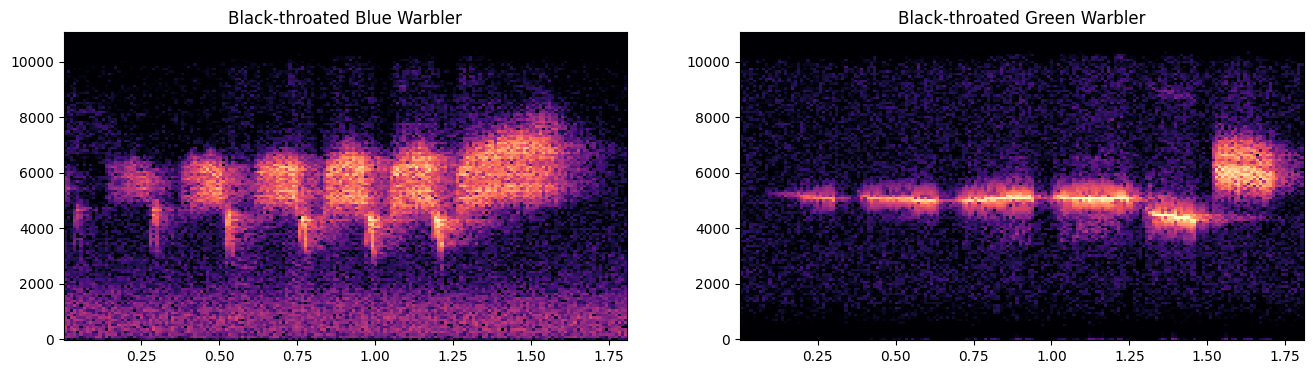

In [15]:
plot_sigx2(d1[25000:65000], d2[45000:85000], 
           name1='Black-throated Blue Warbler', name2='Black-throated Green Warbler', cwt=False, db_range=120)

One major difference between the Fourier transform and wavelet transform is that using the latter we do not have to worry about using a window function to avoid discontinuities, since wavelets are not continuous functions. We can illustrate this by loading a 10s recording, and then compare the coefficients we get by doing the transform on one 10s segment with 10 times 1s segments concatenated. Let's try a recording of the Northern Mockingbird - a bird that basically never makes the same song twice...

In [16]:
d3 = rd_file(TRAIN_DIR+'/normoc/XC54018.mp3', offset=127, duration=10)
Audio(d3, rate=SR)

data type: float32
data size should be 882000.0
size of rd_file data: 882000


size of x: 441000, memory of x 1764000
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.8159

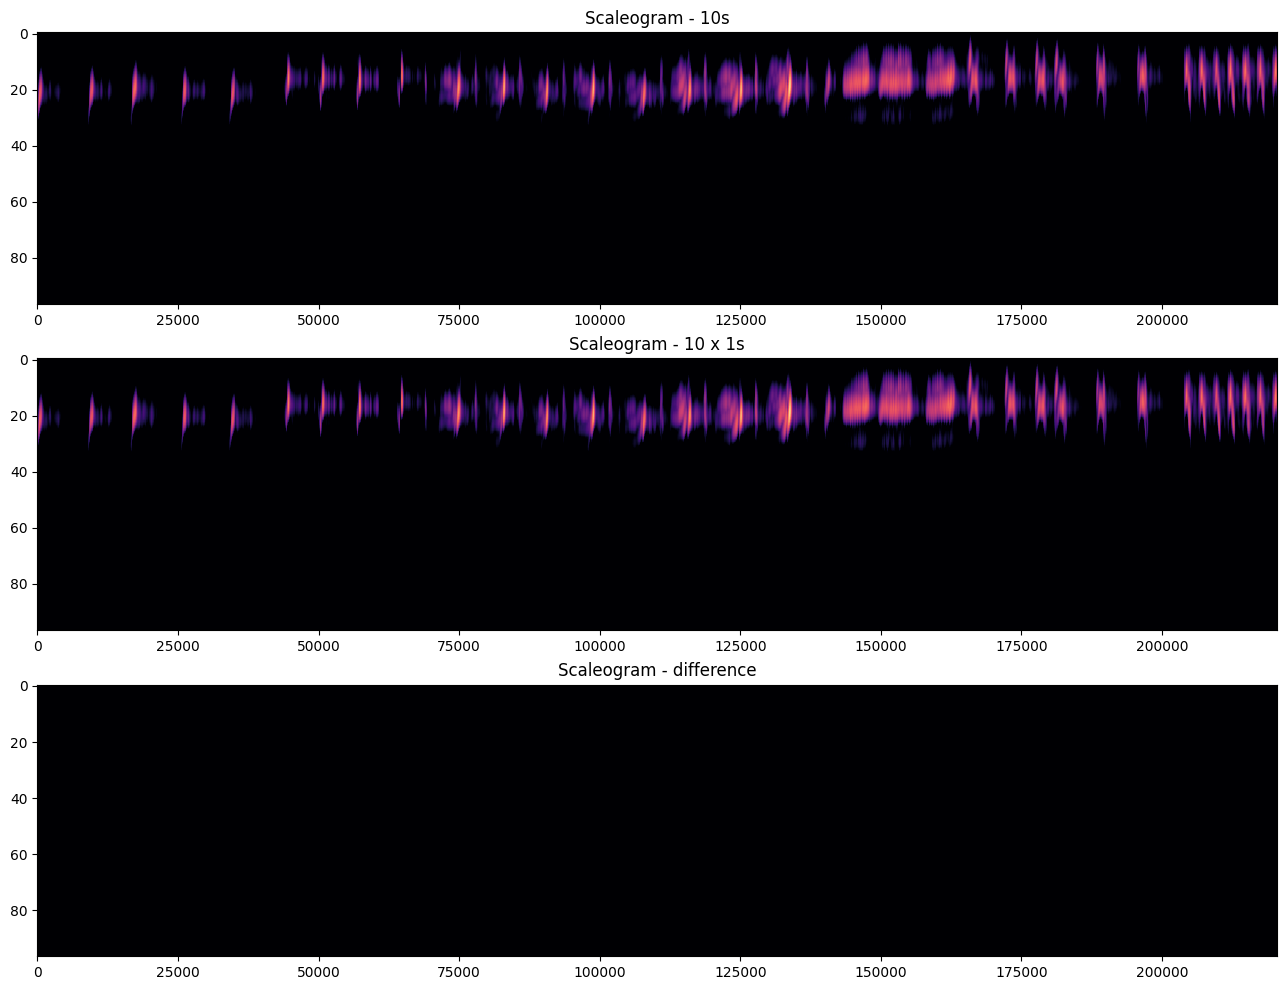

In [17]:
cs3a, f3 = cwt2(d3, nv=12, sr=SR, low_freq=40)
cs3b=np.zeros((97,10*SR), dtype=np.complex)
for i in range(10):
    cs3b[:,i*SR:(i+1)*SR], _ = cwt2(d3[i*SR:(i+1)*SR], nv=12, sr=SR, low_freq=40)
fig, axes = plt.subplots(3, 1, figsize=(16,12))
axes[0].imshow(20*np.log10(np.abs(cs3a)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-40)
axes[0].set_title('Scaleogram - 10s')
axes[1].imshow(20*np.log10(np.abs(cs3b)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-40)
axes[1].set_title('Scaleogram - 10 x 1s')
diff = np.abs(np.abs(cs3a)-np.abs(cs3b))
diff[diff == 0.] = 1e-15
axes[2].imshow(20*np.log10(diff), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-40)
axes[2].set_title('Scaleogram - difference')
plt.show()

The scaleograms are identical - we can apply the CWT on a signal length optimized for available CPU power and memory, and split and concatenate the coefficients whichever way we want! Now, repeat same exercise with spectrogram.

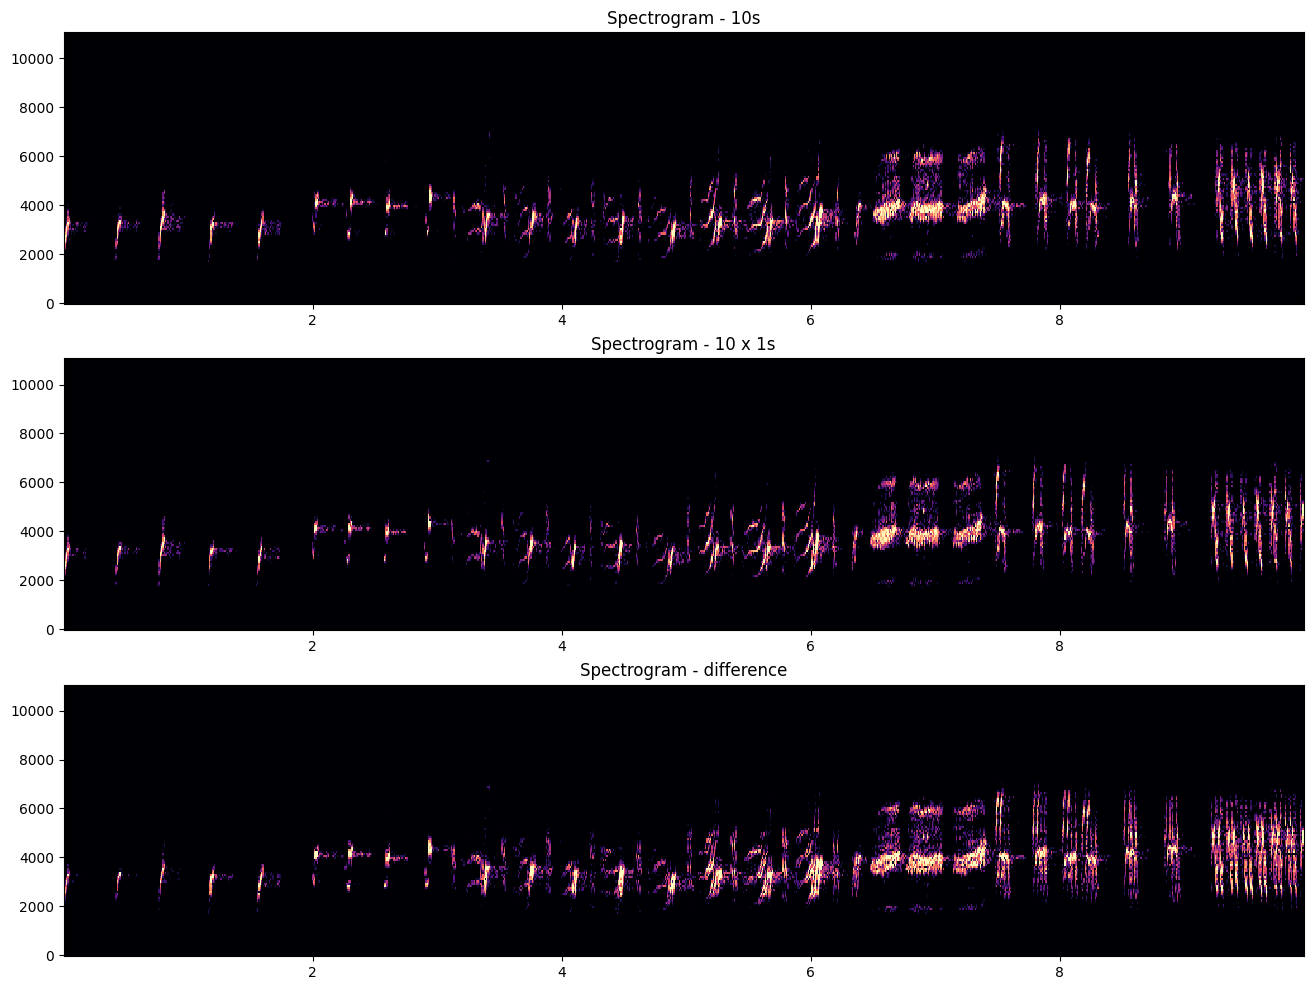

In [18]:
f, t, Sxxa = signal.spectrogram(d3, SR)
Sxxb=np.zeros((129,10*98))
for i in range(10):
    _, _, Sxxb[:,i*98:(i+1)*98] = signal.spectrogram(d3[i*SR:(i+1)*SR])
fig, axes = plt.subplots(3, 1, figsize=(16,12))
axes[0].pcolormesh(t[0:980], f, 20*np.log10(Sxxa[:,0:980]), shading='auto', cmap=CMAP, vmax=-90, vmin=-130)
axes[0].set_title('Spectrogram - 10s')
axes[1].pcolormesh(t[0:980], f, 20*np.log10(Sxxb), shading='auto', cmap=CMAP, vmax=-0, vmin=-40)
axes[1].set_title('Spectrogram - 10 x 1s')
diff = np.abs(np.abs(Sxxa[:,0:980]*3e4)-np.abs(Sxxb))
diff[diff == 0.] = 1e-15
axes[2].pcolormesh(t[0:980], f, 20*np.log10(diff), shading='auto', cmap=CMAP, vmax=-0, vmin=-40)
axes[2].set_title('Spectrogram - difference')
plt.show()

As, we can see, the spectrogram is a lot more complicated - coefficient scaling is different and we do not even get the same number of coefficients for a 10s as with 10x 1s. A summary so far:  
* Spectrogram (based on FFT): Easy to understand, hard to use
* Scaleogram (based on CWT): Hard to understand, easy to use.

So, what we need now is an automated way of extracting these bird signatures, and dump the signatures to jpeg files as input to an image classification model. There are many ways to locate signatures in recordings, and a basic, rule-based one is used below. Of course, these are easy birds, and more difficult birds (or noisy recordings) present a whole range of challenges...

In [19]:
# load another file with XC51863
fn_63 = TRAIN_DIR+'/btbwar/XC51863.mp3'
d4 = rd_file(fn_63)
Audio(d4, rate=SR)

data type: float32
data size should be 1691136.0
size of rd_file data: 1691136


In [20]:
import noisereduce as nr
import soundfile as sf
from sound import append_suffix, change_ext

reduced_noise = nr.reduce_noise(y=d4, sr=SR)
reduce_fn = change_ext(fn_63, '.wav')
reduce_fn = append_suffix(reduce_fn, 'denoised')
sf.write(reduce_fn, reduced_noise, SR)

In [4]:
reduce_fn = f'{TRAIN_DIR}/btbwar/XC51863_denoised.wav'
d5 = rd_file(reduce_fn)
Audio(d5, rate=SR)

data type: float32
data size should be 1691136.0
size of rd_file data: 1691136


In [5]:
from cwt import plot_scalogram, calc_scales
import pywt
from util import replace_zeroes

In [ ]:

plot_scalogram(d5, sr=SR, wavename='cmor1.5-1')

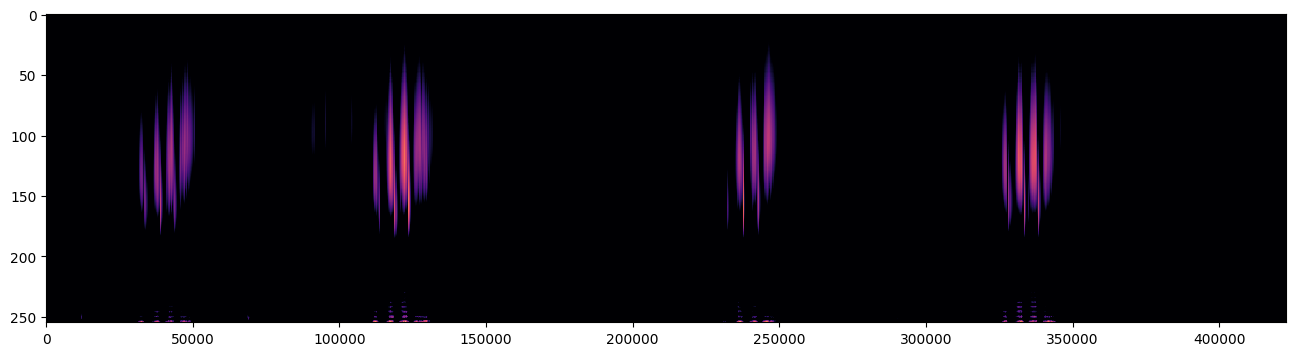

In [6]:
wavename= 'cmor1.5-1'
scales = calc_scales(256, wavename)
cwtmatr, frequencies = pywt.cwt(d5, scales, wavename, 1.0 / SR)

cwt7 = replace_zeroes(cwtmatr)

plt.figure(figsize = (16,4))
plt.imshow(20*np.log10(np.abs(cwt7)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-30)
plt.show()

size of x: 845568, memory of x 3382272
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.8159

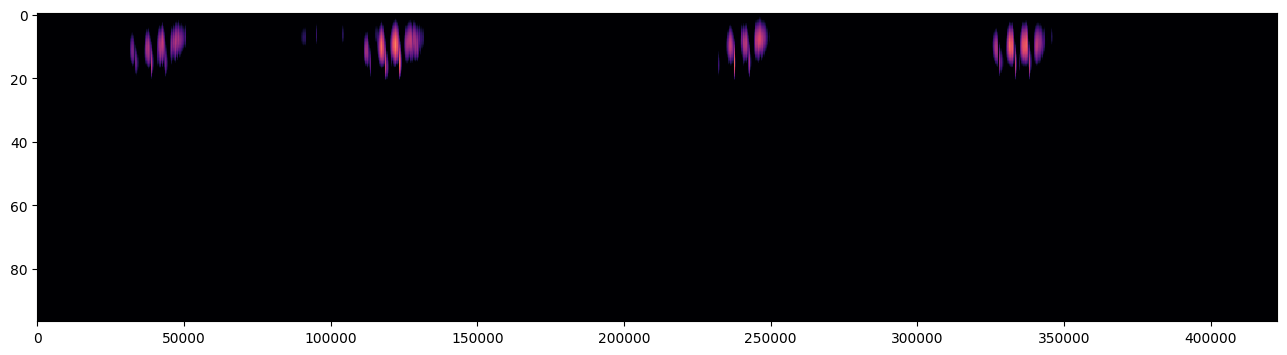

In [25]:
cs5, f5 = cwt2(d5, nv=12, sr=SR, low_freq=40)
plt.figure(figsize = (16,4))
plt.imshow(20*np.log10(np.abs(cs5)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-30)
plt.show()

num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.81591202 128.         135.61127608 143.6751

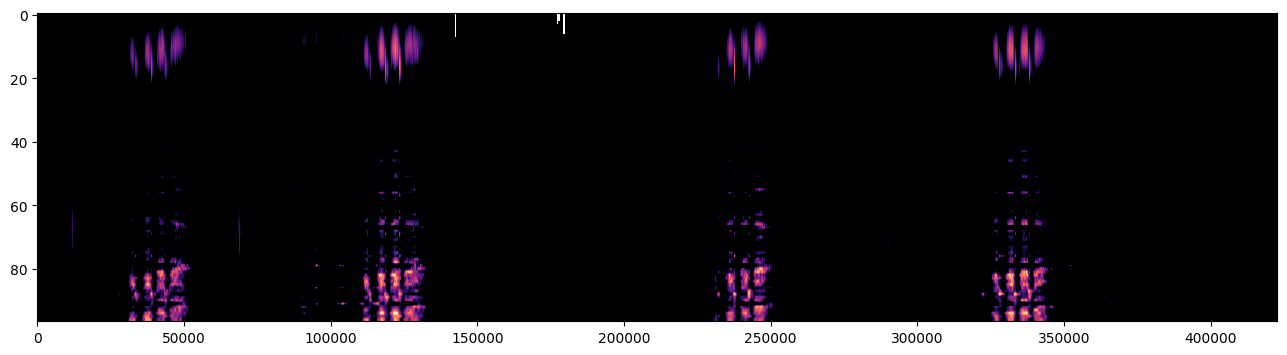

In [26]:
cs6, f6 = cwt3(d5, nv=12, sr=SR, low_freq=40)
plt.figure(figsize = (16,4))
plt.imshow(20*np.log10(np.abs(cs6)), cmap=CMAP, aspect='auto', norm=None, vmax=0, vmin=-30)
plt.show()